# Level 3 — Task 2: NLP Text Classification

In [1]:
# Mount + Install + Import
from google.colab import drive
drive.mount('/content/drive')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
#  Load and Prepare Dataset
df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/3) Sentiment dataset.csv')

# Clean whitespace
df['Sentiment'] = df['Sentiment'].str.strip()
df['Text']      = df['Text'].str.strip()

# 191 unique sentiment ache — 3 ta main group e map kori
positive_list = ['Positive', 'Joy', 'Excitement', 'Contentment',
                 'Gratitude', 'Serenity', 'Happy', 'Hopeful',
                 'Pride', 'Awe', 'Nostalgia']
negative_list = ['Negative', 'Sad', 'Despair', 'Grief',
                 'Loneliness', 'Anger', 'Fear', 'Disgust', 'Boredom']

def map_sentiment(s):
    if s in positive_list:
        return 'Positive'
    elif s in negative_list:
        return 'Negative'
    else:
        return 'Neutral'

df['label'] = df['Sentiment'].apply(map_sentiment)

print("Label Distribution:")
print(df['label'].value_counts())
print("\nSample data:")
print(df[['Text', 'label']].head(5))

Label Distribution:
label
Neutral     449
Positive    228
Negative     55
Name: count, dtype: int64

Sample data:
                                          Text     label
0        Enjoying a beautiful day at the park!  Positive
1           Traffic was terrible this morning.  Negative
2          Just finished an amazing workout! 💪  Positive
3  Excited about the upcoming weekend getaway!  Positive
4  Trying out a new recipe for dinner tonight.   Neutral


In [3]:
# Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    text   = str(text).lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['Text'].apply(preprocess_text)

print("Sample cleaned text:")
print(df[['Text', 'cleaned_text', 'label']].head(5).to_string())

Sample cleaned text:
                                          Text                      cleaned_text     label
0        Enjoying a beautiful day at the park!       enjoying beautiful day park  Positive
1           Traffic was terrible this morning.          traffic terrible morning  Negative
2          Just finished an amazing workout! 💪          finished amazing workout  Positive
3  Excited about the upcoming weekend getaway!  excited upcoming weekend getaway  Positive
4  Trying out a new recipe for dinner tonight.  trying new recipe dinner tonight   Neutral


In [4]:
# TF-IDF + Train-Test Split
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X     = tfidf.fit_transform(df['cleaned_text'])
y     = df['label']

print(f"Feature Matrix Shape: {X.shape}")
print(f"\nLabel Distribution:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Feature Matrix Shape: (732, 3000)

Label Distribution:
label
Neutral     449
Positive    228
Negative     55
Name: count, dtype: int64

Train size: (585, 3000)
Test size : (147, 3000)


In [5]:
# Train and Evaluate Models
results = {}

# Model 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
results['Naive Bayes'] = acc_nb

print("="*45)
print("Model: Naive Bayes")
print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Model 2: Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['Logistic Regression'] = acc_lr

print("="*45)
print("Model: Logistic Regression")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Model: Naive Bayes
Accuracy : 0.6463
Precision: 0.5981
Recall   : 0.6463
F1 Score : 0.5768

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        11
     Neutral       0.65      0.93      0.76        90
    Positive       0.65      0.24      0.35        46

    accuracy                           0.65       147
   macro avg       0.43      0.39      0.37       147
weighted avg       0.60      0.65      0.58       147

Model: Logistic Regression
Accuracy : 0.6531
Precision: 0.6194
Recall   : 0.6531
F1 Score : 0.5765

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        11
     Neutral       0.65      0.96      0.77        90
    Positive       0.71      0.22      0.33        46

    accuracy                           0.65       147
   macro avg       0.45      0.39      0.37       147
weighted avg       0.62      0.65      0.58       147



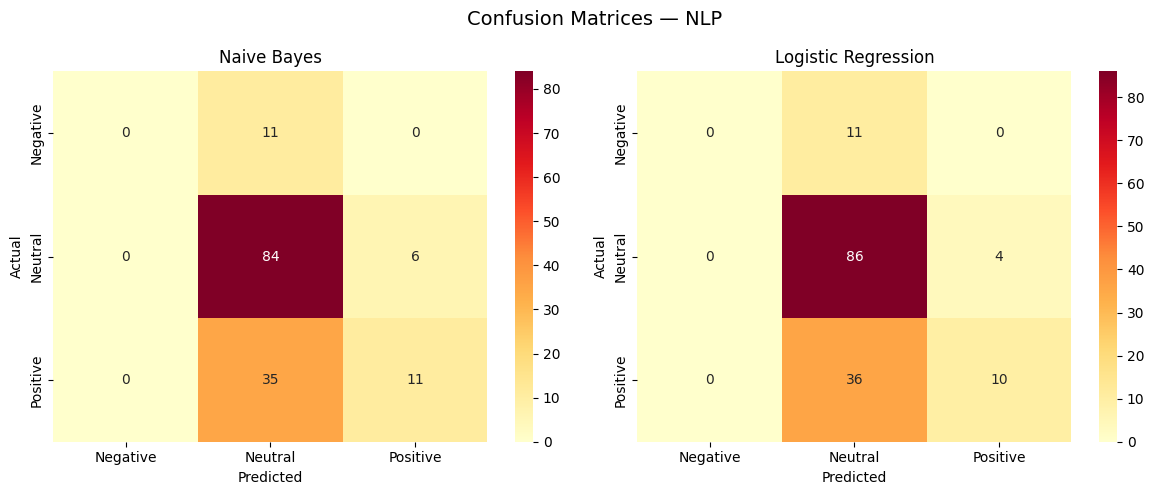

In [6]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Negative', 'Neutral', 'Positive']

for ax, (name, pred) in zip(axes, [
    ("Naive Bayes",         y_pred_nb),
    ("Logistic Regression", y_pred_lr)
]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='YlOrRd',
                xticklabels=labels,
                yticklabels=labels)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — NLP', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_confusion.png')
plt.show()

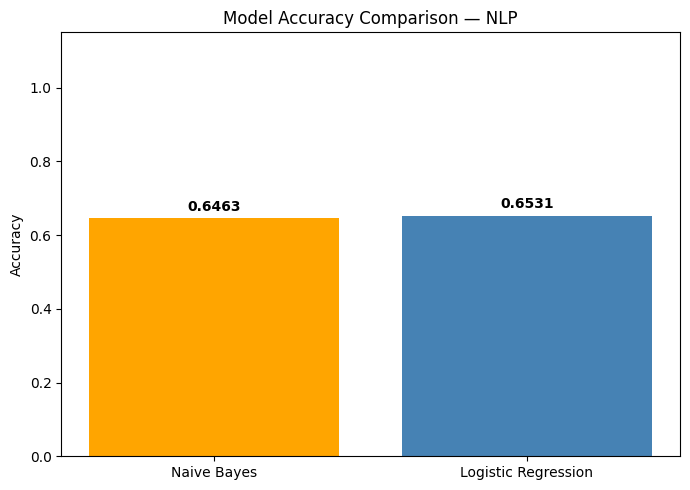

      NLP SUMMARY REPORT
Total Samples   : 732
Features (TF-IDF): 3000

Label Distribution:
label
Neutral     449
Positive    228
Negative     55
Name: count, dtype: int64

Naive Bayes Accuracy      : 0.6463
Logistic Regression Accuracy: 0.6531

Best Model: Logistic Regression


In [7]:
# Model Comparison + Summary
plt.figure(figsize=(7, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['orange', 'steelblue'])
plt.title('Model Accuracy Comparison — NLP')
plt.ylabel('Accuracy')
plt.ylim(0, 1.15)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/nlp_comparison.png')
plt.show()

print("="*50)
print("      NLP SUMMARY REPORT")
print("="*50)
print(f"Total Samples   : {len(df)}")
print(f"Features (TF-IDF): 3000")
print(f"\nLabel Distribution:\n{df['label'].value_counts()}")
print(f"\nNaive Bayes Accuracy      : {acc_nb:.4f}")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
best = max(results, key=results.get)
print(f"\nBest Model: {best}")
print("="*50)